**Names of all group members:**


---

All code below is only suggestive and you may as well use different approaches.

In [17]:
import seaborn as sns

sns.set_style('white')

In [18]:
# Exercise 1.
import numpy as np
np.random.seed(0)  # for reproducibility

# simulate explanatory variables x (the age and monthly income are assumed here to follow a continous uniform distribution)

m=20_000
n=10_000

def generate_dataset(n_samples: int):
    return np.hstack([
        np.random.uniform(18, 80, size=(n_samples, 1)),
        np.random.uniform(1, 15, size=(n_samples, 1)),
        np.random.binomial(1, 0.1, size=(n_samples, 1))
    ])


# data_m=generate_dataset(m)
# data_n=generate_dataset(n)
data_mn=generate_dataset(m+n)

# check self-employed proportion
epsilon=0.005
assert np.sum(data_mn[:,2])/data_mn.shape[0] < 0.1 + epsilon
assert np.sum(data_mn[:,2])/data_mn.shape[0] > 0.1 - epsilon

# a) calculate empirical means and standard deviations over training data

data_mean=data_mn.mean(axis=0)
data_std=data_mn.std(axis=0)

# b) Can you come up with a few (2 or 3) additional features that may be relevant?
# (you don't have to implement those of course, just write down your answer in text)
#
# credit history, assets, debt to income ratio, employment stability


In [19]:
# Exercise 2.
# Building the datasets:

sigmoid=lambda x: 1. / (1. + np.exp(-x))

epsiloni=np.random.uniform(0,1, size=m + n)

def p1(x):
    return sigmoid(13.3 - 0.33*x[:,0] + 3.5*x[:,1] - 3*x[:,2])

def p2(x):
    return sigmoid(
        5
        - 10 * (x[:,0] < 25).astype(int)
        - 10 * (x[:,0] > 75).astype(int)
        + 1.1 * x[:,1]
        - x[:,2]
    )


def generate_targets(x, epsilon, s: int):
    # s is either 1 or 2
    p=p1 if s == 1 else p2 # 1=good or 0=bad borrower
    targets=(epsilon <= p(x)).astype(int) # conditional on targets
    # print(targets.shape)
    # print(targets.reshape((-1,1)))
    data=np.hstack([x, targets.reshape((-1,1))])
    return data, data[:m,:-1], data[:m,-1], data[m:,:-1], data[m:,-1]

# build the first datasety

data1, train1, train_target1, test1, test_target1=generate_targets(data_mn, epsiloni, 1)

assert data1.shape == (30000,4)
assert train1.shape == (20000,3)
assert train_target1.shape == (20000,)

# build the second dataset

data2, train2, train_target2, test2, test_target2=generate_targets(data_mn, epsiloni, 2)

assert data2.shape == (30000,4)
assert train2.shape == (20000,3)
assert train_target2.shape == (20000,)


print(f"Good borrowers dataset 1: {np.sum(train_target1) + np.sum(test_target1)}")
print(f"Good borrowers dataset 2: {np.sum(train_target2) + np.sum(test_target2)}")

Good borrowers dataset 1: 28553.0
Good borrowers dataset 2: 28477.0


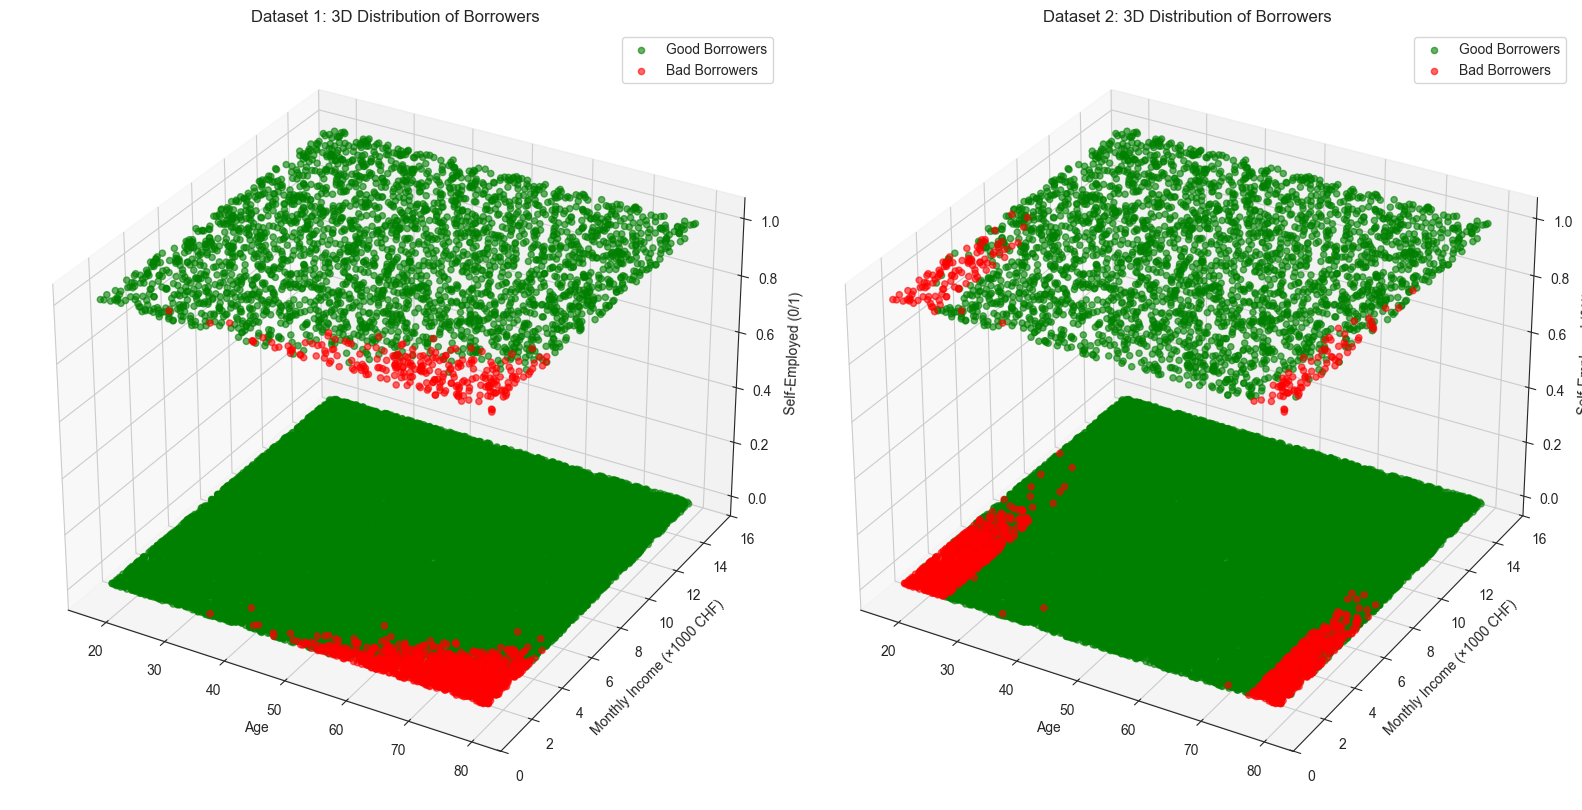

Dataset 1 Statistics:
Total borrowers: 30000
Good borrowers: 28553 (95.2%)
Bad borrowers: 1447 (4.8%)

Dataset 2 Statistics:
Total borrowers: 30000
Good borrowers: 28477 (94.9%)
Bad borrowers: 1523 (5.1%)


In [20]:
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(16, 8))

ax1=fig.add_subplot(121, projection='3d')
good_borrowers_1=data1[data1[:, 3] == 1]  # Good borrowers (target=1)
bad_borrowers_1=data1[data1[:, 3] == 0]   # Bad borrowers (target=0)
ax1.scatter(good_borrowers_1[:, 0], good_borrowers_1[:, 1], good_borrowers_1[:, 2], 
           c='green', alpha=0.6, s=20, label='Good Borrowers')
ax1.scatter(bad_borrowers_1[:, 0], bad_borrowers_1[:, 1], bad_borrowers_1[:, 2], 
           c='red', alpha=0.6, s=20, label='Bad Borrowers')
ax1.set_xlabel('Age')
ax1.set_ylabel('Monthly Income (×1000 CHF)')
ax1.set_zlabel('Self-Employed (0/1)')
ax1.set_title('Dataset 1: 3D Distribution of Borrowers')
ax1.legend()

ax2=fig.add_subplot(122, projection='3d')
good_borrowers_2=data2[data2[:, 3] == 1]  # Good borrowers (target=1)
bad_borrowers_2=data2[data2[:, 3] == 0]   # Bad borrowers (target=0)
ax2.scatter(good_borrowers_2[:, 0], good_borrowers_2[:, 1], good_borrowers_2[:, 2], 
           c='green', alpha=0.6, s=20, label='Good Borrowers')
ax2.scatter(bad_borrowers_2[:, 0], bad_borrowers_2[:, 1], bad_borrowers_2[:, 2], 
           c='red', alpha=0.6, s=20, label='Bad Borrowers')
ax2.set_xlabel('Age')
ax2.set_ylabel('Monthly Income (×1000 CHF)')
ax2.set_zlabel('Self-Employed (0/1)')
ax2.set_title('Dataset 2: 3D Distribution of Borrowers')
ax2.legend()

plt.tight_layout()
plt.show()

print("Dataset 1 Statistics:")
print(f"Total borrowers: {data1.shape[0]}")
print(f"Good borrowers: {good_borrowers_1.shape[0]} ({good_borrowers_1.shape[0]/data1.shape[0]*100:.1f}%)")
print(f"Bad borrowers: {bad_borrowers_1.shape[0]} ({bad_borrowers_1.shape[0]/data1.shape[0]*100:.1f}%)")

print("\nDataset 2 Statistics:")
print(f"Total borrowers: {data2.shape[0]}")
print(f"Good borrowers: {good_borrowers_2.shape[0]} ({good_borrowers_2.shape[0]/data2.shape[0]*100:.1f}%)")
print(f"Bad borrowers: {bad_borrowers_2.shape[0]} ({bad_borrowers_2.shape[0]/data2.shape[0]*100:.1f}%)")

In [21]:
# Exercise 2. a)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
# "model=LogisticRegression().fit(X_data, Y_data)" fits a model
# "pred_X=model.predict_proba(X)" evaluates the model
# (note that it outputs both P(Y=0|X) and P(Y=1|X))
# "log_loss(Y, pred_X)" evaluates the negative conditional log likelihood (also called cross-entropy loss)

# Fit the models on both datasets

model1=LogisticRegression().fit(train1, train_target1)
model2=LogisticRegression().fit(train2, train_target2)

# Calculate cross-entropy loss on both datasets for train and test

def manual_log_loss(y : np.array, y_pred_proba : np.array, epsilon=1e-15):
    "log_loss for multinomial output"
    y_pred_proba=np.clip(y_pred_proba, epsilon, 1 - epsilon)
    return -np.mean(np.log(y_pred_proba[np.arange(len(y)).astype("int"), y.astype("int")]))

pred1_proba_LOG=model1.predict_proba(test1)
print(f"Train loss Logistic Regression (1): {log_loss(train_target1, model1.predict_proba(train1)):.3f}")
print(f"Test loss Logistic Regression (1): {log_loss(test_target1, pred1_proba_LOG):.3f}")
# print(manual_log_loss(test_target1, pred1_proba_LOG))

pred2_proba_LOG=model2.predict_proba(test2)
print(f"Train loss Logistic Regression (2): {log_loss(train_target2, model2.predict_proba(train2)):.3f}")
print(f"Test loss Logistic Regression (2): {log_loss(test_target2, pred2_proba_LOG):.3f}")
# print(manual_log_loss(test_target2, pred2_proba_LOG))

Train loss Logistic Regression (1): 0.030
Test loss Logistic Regression (1): 0.035
Train loss Logistic Regression (2): 0.154
Test loss Logistic Regression (2): 0.149


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_predi

The logistic regression performs well on dataset 1, both in and out of sample. As expected, the logistic regression performs quite bad on dataset 2 which has nonlinear decision boundaries.

In [22]:
# Exercise 2. b)
# Calculate normalized data

empirical_std1=train1.std(axis=0)
train1 /= empirical_std1
test1 /= empirical_std1

empirical_std2=train2.std(axis=0)
train2 /= empirical_std2
test2 /= empirical_std2

assert train1.std(axis=0).all() == 1
assert train2.std(axis=0).all() == 1

print(f"Standard deviation for each feature in dataset 1: {test1.std(axis=0)}")
print(f"Standard deviation for each feature in dataset 2: {test2.std(axis=0)}")

Standard deviation for each feature in dataset 1: [0.99583013 1.00011568 1.00217617]
Standard deviation for each feature in dataset 2: [0.99583013 1.00011568 1.00217617]


The standard deviations are all close to 1 for all features for both datasets.

In [23]:
# Exercise 2.b) (i) and (ii)
from sklearn.svm import SVC
# "model=SVC(kernel='rbf', gamma=GAMMA, C=C, probability=True)" creates
# a model with kernel exp(-GAMMA \|x-x'\|_2^2) and regul. parameter C (note the relation between C and the parameter lambda from the lecture).
# "probability=True" enables the option "model.predict_proba(X)" to predict probabilities from the regression function \hat{f}^{svm}.
# "model.fit(X, Y)" optimizes the model parameters (using hinge loss)

# Fit the models for both datasets (this can take up to 60 seconds with SVC)

model1=SVC(kernel='rbf', gamma=1/10, C=0.2, probability=True)
model2=SVC(kernel='rbf', gamma=1/10, C=0.2, probability=True)

model1.fit(train1, train_target1)
model2.fit(train2, train_target2)

pred1_proba_SVM=model1.predict_proba(test1)
pred2_proba_SVM=model2.predict_proba(test2)


In [24]:
# Exercise 2.b (iii)
# "model.predict_proba(X)" predicts probabilities from features (note that it outputs both P(Y=0|X) and P(Y=1|X))

# Calculate cross-entropy loss on both normalized datasets for train and test

print(f"Train loss SVM (1): {log_loss(train_target1, model1.predict_proba(train1)):.3f}")
print(f"Test loss SVM (1): {log_loss(test_target1, pred1_proba_SVM):.3f}")

print(f"Train loss SVM (2): {log_loss(train_target2, model2.predict_proba(train2)):.3f}")
print(f"Train loss SVM (2): {log_loss(test_target2, pred2_proba_SVM):.3f}")

Train loss SVM (1): 0.032
Test loss SVM (1): 0.039
Train loss SVM (2): 0.071
Train loss SVM (2): 0.067


We notice that SVM performs equally, perhaps even slighly worse than the logistic regression on dataset 1, but it is clearly superior in dataset 2, due to the nonlinear decision boundary for this SVM with radial kernel.

In [25]:
# Exercise 2.b (iv)
#Would the results change using standardized data instead of normalized data? No need to run any code here, only explain your reasoning.

# Nothing would change, substracting the mean is only a linear shift in spaces, and the decision boundary stays the same relative to the data.

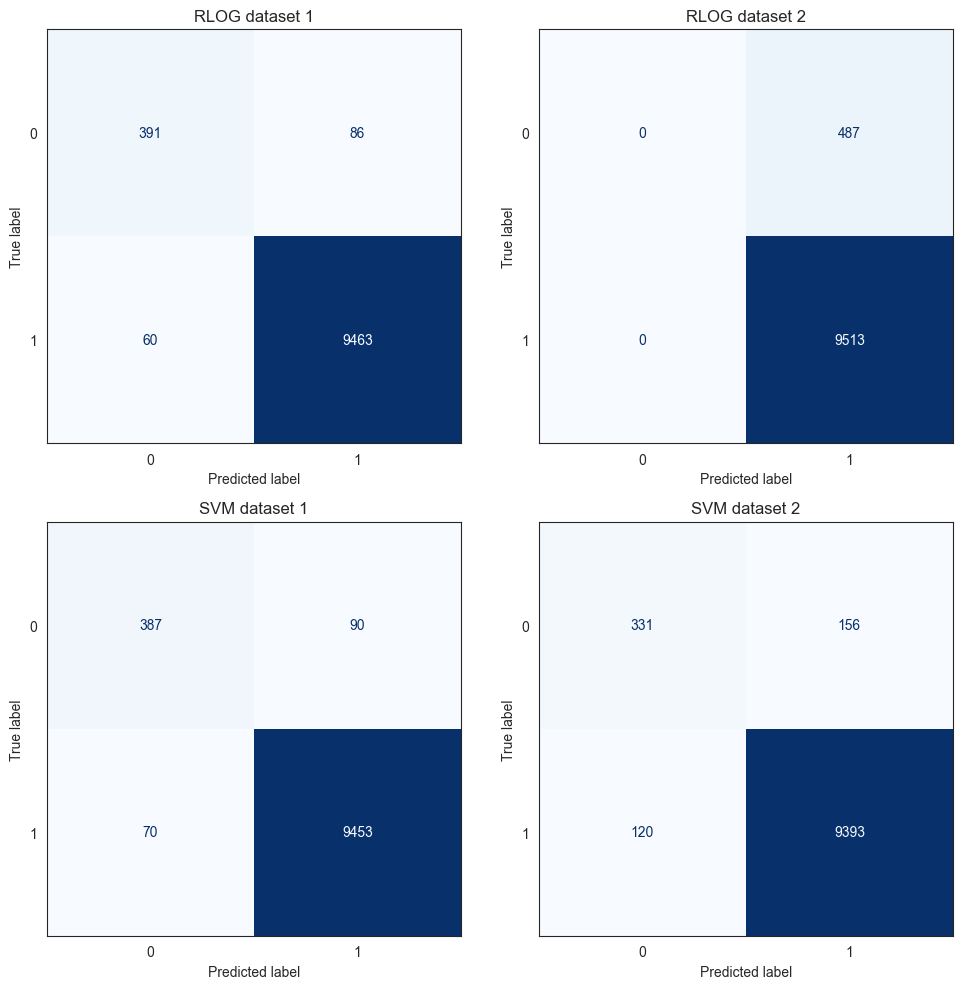

In [26]:
# plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds=[
    np.argmax(pred1_proba_LOG, axis=1),
    np.argmax(pred2_proba_LOG, axis=1),
    np.argmax(pred1_proba_SVM, axis=1),
    np.argmax(pred2_proba_SVM, axis=1)
]

titles=["RLOG dataset 1", "RLOG dataset 2", "SVM dataset 1", "SVM dataset 2"]
fig, ax=plt.subplots(2,2, figsize=(10,10))
for i, (pred, title) in enumerate(zip(preds, titles)):
    row, col=divmod(i,2)
    cm=confusion_matrix(test_target1 if col == 0 else test_target2, pred)
    disp=ConfusionMatrixDisplay(cm)
    disp.plot(ax= ax[row, col], colorbar=False, cmap="Blues")
    ax[row, col].set_title(title)

plt.tight_layout()
plt.show()

For dataset 1 both logistic regression and SVM performs almost equally good.

For dataset 2 the logistic regression classifies everything as good, thus the FPR is very high. This is not good for our use case, since classifying a bad borrower as a good one will incur losses.

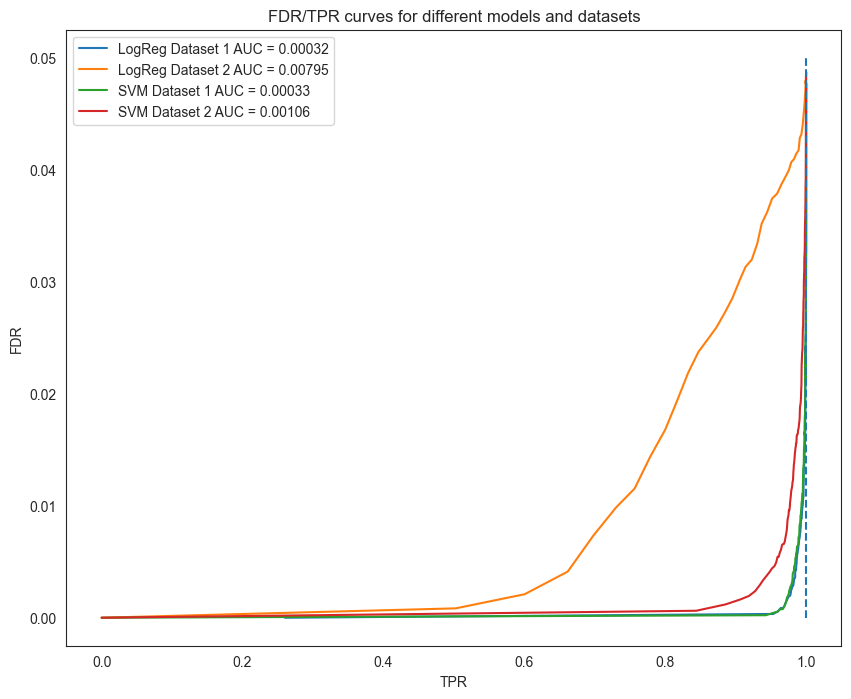

In [36]:
# Exercise 2.c
import matplotlib.pyplot as plt
# To calculate the curves, it is fine to take 100 threshold values c, i.e.,
ths = np.linspace(0, 1, 100)

# To approximately calculate the AUC, it is fine to simply use Riemann sums.
# This means, if you have 100 (a_i, b_i) pairs for the curves, a_1 <= a_2 <= ...
# then you may simply use the sum
# sum_{i=1}^99 (b_i + b_{i+1})/2 * (a_{i+1}-a_i)
# as the approximation of the integral (or AUC)


# first data set & logistic regression:
# (the code should be reusable for all cases, only exchanging datasets and predicted probabilities depending on the model)

# Calculate positives (only depending on the dataset)

def compute_FDR_TPR(y_true, y_pred_proba):

    TPR = []
    FDR = []

    positives = np.sum(y_true)
    for threshold in ths:
        tp = 0
        fp = 0
        for i in range(y_true.shape[0]):
            if y_pred_proba[i,1] >= threshold:
                if y_true[i] == 1:
                    tp += 1
                else:
                    fp += 1

        TPR.append(tp/positives if positives > 0 else 0)
        FDR.append(fp/(fp + tp) if fp + tp > 0 else 0)

    ind = np.argsort(TPR)
    FDR = np.array(FDR)[ind]
    TPR = np.array(TPR)[ind]
    return FDR, TPR

FDR, TPR = compute_FDR_TPR(test_target1, pred1_proba_LOG)

def compute_AUC_FDR_TPR(FDR, TPR):
    assert FDR.shape == TPR.shape
    AUC = 0
    for i in range(FDR.shape[0]-1):
        AUC += (FDR[i] + FDR[i+1])/ 2 *(TPR[i+1] - TPR[i])
    return AUC
# Calculate true positives for all threshold values

# Calculate false positives for all threshold values

# Calculate FPR and TPR rate (points on the FPR/TPR curve) and the AUC

plt.figure(figsize = (10,8))
plt.xlabel("TPR")
plt.ylabel("FDR")
plt.title("FDR/TPR curves for different models and datasets")

FDR_LogReg1, TPR_LogReg1 = compute_FDR_TPR(test_target1, pred1_proba_LOG)
AUC_LogReg1 = compute_AUC_FDR_TPR(FDR_LogReg1, TPR_LogReg1)
plt.plot(TPR_LogReg1,FDR_LogReg1, label = f"LogReg Dataset 1 AUC = {round(AUC_LogReg1, 5)}")

FDR_LogReg2, TPR_LogReg2 = compute_FDR_TPR(test_target2, pred2_proba_LOG)
AUC_LogReg2 = compute_AUC_FDR_TPR(FDR_LogReg2, TPR_LogReg2)
plt.plot(TPR_LogReg2,FDR_LogReg2, label = f"LogReg Dataset 2 AUC = {round(AUC_LogReg2, 5)}")

FDR_SVM1, TPR_SVM1 = compute_FDR_TPR(test_target1, pred1_proba_SVM)
AUC_SVM1 = compute_AUC_FDR_TPR(FDR_SVM1, TPR_SVM1)
plt.plot(TPR_SVM1,FDR_SVM1, label = f"SVM Dataset 1 AUC = {round(AUC_SVM1, 5)}")

FDR_SVM2, TPR_SVM2 = compute_FDR_TPR(test_target2, pred2_proba_SVM)
AUC_SVM2 = compute_AUC_FDR_TPR(FDR_SVM2, TPR_SVM2)
plt.plot(TPR_SVM2,FDR_SVM2, label = f"SVM Dataset 2 AUC = {round(AUC_SVM2, 5)}")

plt.vlines(1, 0, 0.05, linestyles = "--")
plt.legend()

plt.show()

# second data set & logistic regression:

# first data set and rkhs regression:

# second data set and rkhs regression:

Both models perform very well on Dataset 1. On Dataset 2, SVM yields consistently lower FDR at the same TPR than logistic regression.

In [28]:
# Exercise 3.

# Set model parameters and define matrix D

d=data_mn[m:,:]

loan_amount=1000
interest_rate_1=0.055 
interest_rate_2=0.01  
interest_rate_3=0.01
scenarios=50_000

epsilon_n_k=np.random.uniform(0,1, size =(n, scenarios))

def generate_D(epsilon_n_k):
    l = []
    for k in range(epsilon_n_k.shape[1]):
        l.append((epsilon_n_k[:,k] <= p2(d)).reshape(-1,1))
    return np.hstack(l).astype("int")

D = generate_D(epsilon_n_k)

In [29]:
def compute_outcomes(portfolio, D_matrix):
    delinquent_k=[]
    repaid_k=[]
    for k in range(D_matrix.shape[1]):
        selected=D_matrix[:,k][portfolio]
        delinquent_k.append(np.bincount(selected)[0])
        repaid_k.append(np.bincount(selected)[1])
    return np.array(repaid_k), np.array(delinquent_k)


def compute_expected_profit_VaR(profits):
    mean_profit=np.mean(profits)
    VaR=np.percentile(profits, 5)
    return mean_profit, VaR

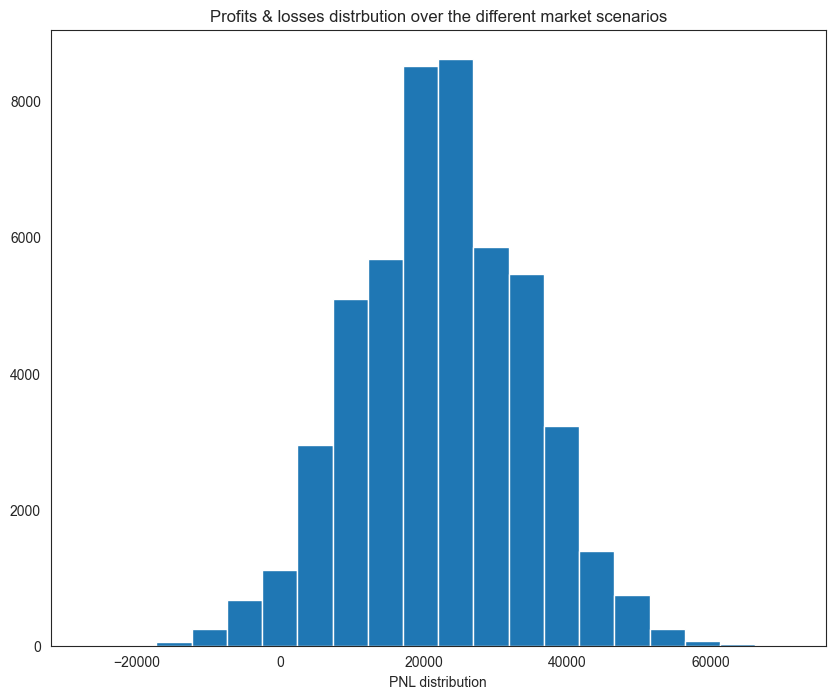

expected profit: 22360.06
neg 95% quantile: 2455.00


In [30]:
# Scenario 1:
# Define Portfolio and possible outcomes for this portfolio using matrix D

def portfolio_I():
    "1000 CHF loan to everyone charging 5.5% interest rate"
    return np.where(np.ones_like(test_target2) == 1)[0]

repaid_I, delinquent_I=compute_outcomes(portfolio=portfolio_I(), D_matrix=D)

def PnL(repaid_I, delinquent_I, rate):
    PNL_k=[]
    for p,l in zip(repaid_I, delinquent_I):
        PNL_k.append((loan_amount *  rate * p) - (loan_amount * l))
    return np.array(PNL_k)

# Plot histogram of profits and losses
plt.figure(figsize=(10,8))
plt.hist(PnL(repaid_I, delinquent_I, interest_rate_1), bins=20)
plt.title("Profits & losses distrbution over the different market scenarios")
plt.xlabel("PNL distribution")
plt.show()

# Calculate expected profit and losses and 95%-VaR

mean_profit_I, VaR_I=compute_expected_profit_VaR(PnL(repaid_I, delinquent_I, interest_rate_1))

print(f"expected profit: {mean_profit_I:.2f}")
print(f"neg 95% quantile: {VaR_I:.2f}")

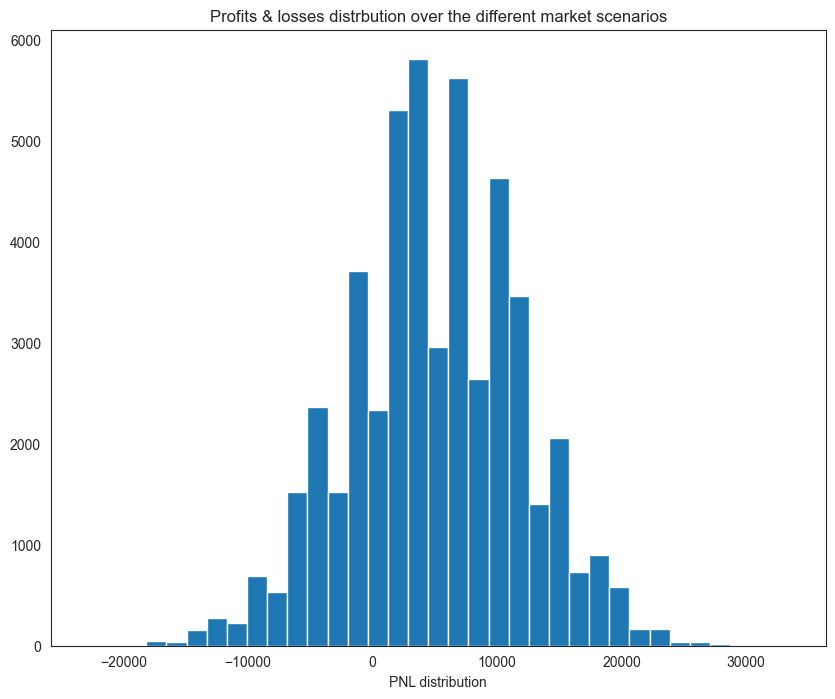

expected profit: 4874.97
neg 95% quantile: -6840.00


In [31]:
# Scenario 2:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the logistic regression model

def portfolio_II():
    "1000 CHF loan p^log_2 >= 0.95, interest rate 1%"
    return np.where((pred2_proba_LOG[:,1] >= 0.95) == 1)[0]

repaid_II, delinquent_II=compute_outcomes(portfolio=portfolio_II(), D_matrix=D)

# Plot histogram of profits and losses

plt.figure(figsize=(10,8))
plt.hist(PnL(repaid_II, delinquent_II, interest_rate_2), bins=35)
plt.title("Profits & losses distrbution over the different market scenarios")
plt.xlabel("PNL distribution")
plt.show()

# Calculate expected profit and losses and 95%-VaR

mean_profit_II, VaR_II=compute_expected_profit_VaR(PnL(repaid_II, delinquent_II, interest_rate_2))

print(f"expected profit: {mean_profit_II:.2f}")
print(f"neg 95% quantile: {VaR_II:.2f}")

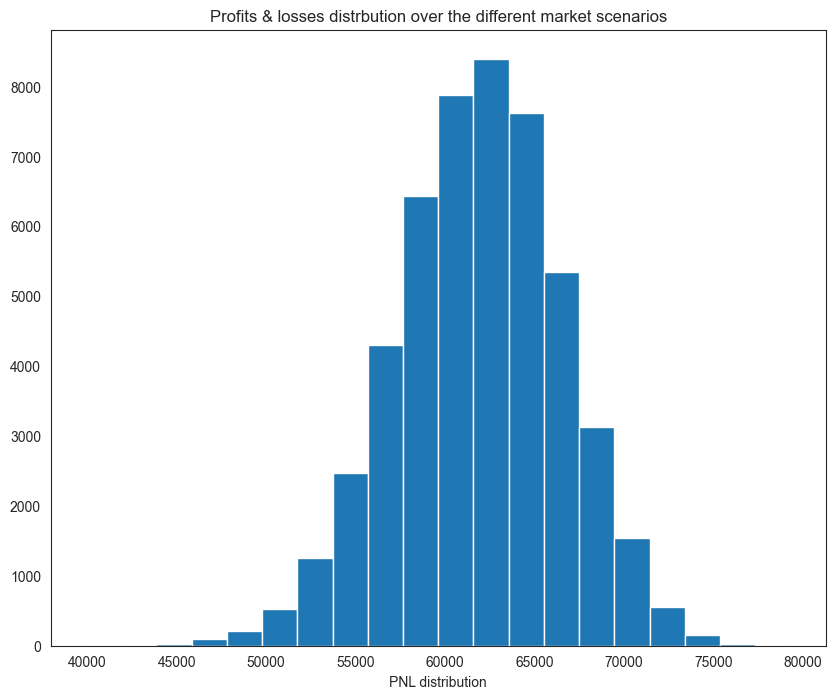

expected profit: 61939.66
neg 95% quantile: 54070.00


In [32]:
# Scenario 3:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the rkhs model

def portfolio_III():
    "1000 CHF loan p^svm_2 >= 0.95, interest rate 1%"
    return np.where((pred2_proba_SVM[:,1] >= 0.95) == 1)


repaid_III, delinquent_III=compute_outcomes(portfolio=portfolio_III(), D_matrix=D)

# Plot histogram of profits & losses (which is simply the performance of each strategy in scenario k, i.e. a profit if positive or a loss if negative)

plt.figure(figsize=(10,8))
plt.hist(PnL(repaid_III, delinquent_III, interest_rate_3), bins=20)
plt.title("Profits & losses distrbution over the different market scenarios")
plt.xlabel("PNL distribution")
plt.show()

# Calculate expected profit & losses and 95%-VaR for each strategy

mean_profit_III, VaR_III=compute_expected_profit_VaR(PnL(repaid_III, delinquent_III, interest_rate_3))

print(f"expected profit: {mean_profit_III:.2f}")
print(f"neg 95% quantile: {VaR_III:.2f}")

We notice that being naive and giving a loan to everyone has an expected profit of CHF 22360, with a VaR CHF 2455. This is suprisingly better than using a logistic regression which yields CHF 4875 and VaR CHF -6840. This is because the logistic regression has a linear decision boundary, and this cannot separate the bad from the good borrowers. For the SVM model, the expected profit is CHF 61940 with a VaR 54070, and clearly performs better than both the naive method and the logistic regression.